In [1]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ──
data_path = '/kaggle/input/datasets/chrisfilo/urbansound8k'
meta_path = '/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv'

# ── Load metadata ──
df = pd.read_csv(meta_path)
print("Metadata loaded:", df.shape)
print(df['class'].value_counts())

# ── GPU check ──
print("\nGPUs available:", tf.config.list_physical_devices('GPU'))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU memory growth enabled")

2026-03-31 15:37:43.587707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774971463.944393      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774971464.045979      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774971464.925879      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774971464.925946      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774971464.925949      24 computation_placer.cc:177] computation placer alr

Metadata loaded: (8732, 8)
class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled


In [2]:
class UrbanSoundGenerator(tf.keras.utils.Sequence):

    def __init__(self, dataframe, data_path, label_encoder,
                 batch_size=32, img_size=(64, 64),
                 augment=False, shuffle=True):
        super().__init__()                              #  fix PyDataset warning
        self.df         = dataframe.reset_index(drop=True)
        self.data_path  = data_path
        self.le         = label_encoder
        self.batch_size = batch_size
        self.img_size   = img_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indexes    = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):
        batch_indexes = self.indexes[
            idx * self.batch_size:(idx + 1) * self.batch_size
        ]
        batch_df = self.df.iloc[batch_indexes]

        X_batch = []
        y_batch = []

        for _, row in batch_df.iterrows():
            file_path = os.path.join(
                self.data_path,
                f"fold{row['fold']}",
                row['slice_file_name']
            )
            try:
                audio, sr = librosa.load(
                    file_path, sr=22050, duration=5
                )

                # ── Augment only training data ──
                if self.augment:
                    choice = np.random.choice(
                        ['original', 'stretch', 'pitch']
                    )
                    if choice == 'stretch':
                        try:
                            audio = librosa.effects.time_stretch(
                                audio, rate=1.1
                            )
                        except:
                            pass
                    elif choice == 'pitch':
                        audio = librosa.effects.pitch_shift(
                            audio, sr=sr, n_steps=2
                        )

                spec = self.audio_to_spectrogram(audio, sr)

            except Exception as e:
                print(f"Error loading file: {e}")
                spec = np.zeros(
                    (self.img_size[0], self.img_size[1], 3),
                    dtype='float32'
                )

            X_batch.append(spec)
            y_batch.append(row['class'])

        X_batch = np.array(X_batch, dtype='float32')
        y_batch = to_categorical(
            self.le.transform(y_batch), num_classes=10
        )
        return X_batch, y_batch

    def audio_to_spectrogram(self, audio, sr):
        # Resample to standard rate
        target_sr = 22050
        if sr != target_sr:
            audio = librosa.resample(
                audio, orig_sr=sr, target_sr=target_sr
            )
            sr = target_sr

        # Pad to minimum length
        min_length    = 2048
        target_length = target_sr * 5
        pad_length    = max(min_length, target_length)
        if len(audio) < pad_length:
            audio = np.pad(
                audio,
                (0, pad_length - len(audio)),
                mode='constant'
            )

        # Dynamic n_fft
        n_fft = min(2048, len(audio))

        # n_mels=64 avoids empty filter warning
        mel = librosa.feature.melspectrogram(
            y=audio, sr=sr,
            n_mels=64,
            n_fft=n_fft,
            hop_length=512
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize to [0, 1]
        mel_min = mel_db.min()
        mel_max = mel_db.max()
        if mel_max - mel_min > 0:
            mel_norm = ((mel_db - mel_min) /
                        (mel_max - mel_min)
                        ).astype(np.float32)
        else:
            mel_norm = np.zeros_like(mel_db, dtype=np.float32)

        # Resize to img_size
        mel_resized = tf.image.resize(
            mel_norm[..., np.newaxis],
            [self.img_size[0], self.img_size[1]]
        ).numpy()

        # Convert grayscale to RGB
        mel_rgb = np.repeat(mel_resized, 3, axis=-1)
        return mel_rgb.astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# ── Label encoder ──
le = LabelEncoder()
le.fit(df['class'])
print("Classes:", le.classes_)

# ── Test generator ──
test_check = UrbanSoundGenerator(
    df.head(32), data_path, le,
    batch_size=32,
    img_size=(64, 64),
    augment=False
)
X_s, y_s = test_check[0]
print(f"Generator OK")
print(f"   X batch: {X_s.shape}")   # (32, 64, 64, 3)
print(f"   y batch: {y_s.shape}")   # (32, 10)

Classes: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


I0000 00:00:1774971517.732268      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Generator OK
   X batch: (32, 64, 64, 3)
   y batch: (32, 10)


In [3]:
def build_vit_model(image_size=64,
                    patch_size=8,
                    projection_dim=32,
                    num_heads=2,
                    transformer_layers=4,
                    num_classes=10):

    num_patches = (image_size // patch_size) ** 2  # 8×8 = 64

    # PatchExtractor as custom layer ──
    class PatchExtractor(layers.Layer):
        def __init__(self, patch_size, **kwargs):
            super().__init__(**kwargs)
            self.patch_size = patch_size

        def call(self, images):
            patches = tf.image.extract_patches(
                images=images,
                sizes=[1, self.patch_size, self.patch_size, 1],
                strides=[1, self.patch_size, self.patch_size, 1],
                rates=[1, 1, 1, 1],
                padding="VALID"
            )
            batch_size  = tf.shape(patches)[0]
            num_patches = patches.shape[1] * patches.shape[2]
            patch_dims  = patches.shape[-1]
            return tf.reshape(
                patches, [batch_size, num_patches, patch_dims]
            )

    # ─ Patch Encoder with positional embedding ─
    class PatchEncoder(layers.Layer):
        def __init__(self, num_patches, projection_dim, **kwargs):
            super().__init__(**kwargs)
            self.num_patches = num_patches
            self.projection  = layers.Dense(units=projection_dim)
            self.position_embedding = layers.Embedding(
                input_dim=num_patches,
                output_dim=projection_dim
            )

        def call(self, patch):
            positions = tf.range(
                start=0, limit=self.num_patches, delta=1
            )
            return (self.projection(patch) +
                    self.position_embedding(positions))

    # MLP block
    def mlp_block(x, units, dropout_rate=0.1):
        for u in units:
            x = layers.Dense(u, activation=tf.nn.gelu)(x)
            x = layers.Dropout(dropout_rate)(x)
        return x

    # Input
    inputs = layers.Input(shape=(image_size, image_size, 3))

    # Extract + encode patches
    patches = PatchExtractor(patch_size)(inputs)
    encoded = PatchEncoder(num_patches, projection_dim)(patches)

    #Transformer Encoder blocks
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim,
            dropout=0.1
        )(x1, x1)
        x2      = layers.Add()([attn, encoded])
        x3      = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3      = mlp_block(
            x3,
            units=[projection_dim * 2, projection_dim],
            dropout_rate=0.1
        )
        encoded = layers.Add()([x3, x2])

    #Classification head
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(0.3)(representation)
    x       = mlp_block(
        representation,
        units=[256, 128],
        dropout_rate=0.3
    )
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Test model builds correctly
vit_test = build_vit_model()
vit_test.summary()
print(f"\n ViT model built successfully")
print(f"  Total params: {vit_test.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, 64, 192)   │          0 │ input_layer[0][0] │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 32)    │      8,224 │ patch_extractor[… │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 32)    │         64 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 32)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 32)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 32)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 32)    │      2,080 │ dropout_4[0][0] 

 Total params: 101,866 (397.91 KB)

 Trainable params: 101,866 (397.91 KB)

 Non-trainable params: 0 (0.00 B)


 ViT model built successfully
  Total params: 101,866


In [4]:
import json

# ── Manually set progress from your JSON file ──
progress_path = '/kaggle/working/cv_progress.json'

# Paste your exact values from the JSON file
progress = {
    'last_fold'  : 8,          # ← last completed fold
    'accuracies' : [
        0.520045816898346,
        0.49436935782432556,
        0.41081079840660095,
        0.5,
        0.4732905924320221,
        0.4179829955101013,
        0.43556085228919983,
        0.5297766923904419
    ],
    'losses' : [
        1.6374586820602417,
        1.3872361183166504,
        1.642992615699768,
        1.417170763015747,
        1.4988398551940918,
        1.5870003700256348,
        1.6301721334457397,
        1.345832347869873
    ],
    'y_true' : [],   # ← leave empty, will be rebuilt from fold 5 model
    'y_pred' : []    # ← leave empty, will be rebuilt from fold 5 model
}

with open(progress_path, 'w') as f:
    json.dump(progress, f)

print("Progress manually set")
print(f"   Last fold    : {progress['last_fold']}")
print(f"   Accuracies   : "
      f"{[f'{a*100:.1f}%' for a in progress['accuracies']]}")

Progress manually set
   Last fold    : 8
   Accuracies   : ['52.0%', '49.4%', '41.1%', '50.0%', '47.3%', '41.8%', '43.6%', '53.0%']


No previous output found — starting fresh

 Resuming from Fold 9
   Completed folds : 8
   Accuracies so far: ['52.0%', '49.4%', '41.1%', '50.0%', '47.3%', '41.8%', '43.6%', '53.0%']

  Fold 9/10
  Train : 7916 samples | 248 batches
  Test  : 816 samples  | 26 batches

 Training Fold 9...


I0000 00:00:1774971539.568215      77 service.cc:152] XLA service 0x7926f0014480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774971539.568265      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774971543.413120      77 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774971556.143950      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.war


Epoch 1: val_accuracy improved from -inf to 0.26593, saving model to /kaggle/working/vit_fold9.keras


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(



Epoch 2: val_accuracy did not improve from 0.26593


...


Epoch 28: val_accuracy did not improve from 0.53405


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(



Epoch 29: val_accuracy did not improve from 0.53405


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(



Epoch 30: val_accuracy did not improve from 0.53405

 Fold 10 → Accuracy: 53.41% | Loss: 1.2842
  Progress saved — Fold 10/10 complete

  ViT — 10-FOLD CROSS VALIDATION RESULTS
  Fold  1 → Accuracy: 52.00%  | Loss: 1.6375
  Fold  2 → Accuracy: 49.44%  | Loss: 1.3872
  Fold  3 → Accuracy: 41.08%  | Loss: 1.6430
  Fold  4 → Accuracy: 50.00%  | Loss: 1.4172
  Fold  5 → Accuracy: 47.33%  | Loss: 1.4988
  Fold  6 → Accuracy: 41.80%  | Loss: 1.5870
  Fold  7 → Accuracy: 43.56%  | Loss: 1.6302
  Fold  8 → Accuracy: 52.98%  | Loss: 1.3458
  Fold  9 → Accuracy: 55.15%  | Loss: 1.2782
  Fold 10 → Accuracy: 53.41%  | Loss: 1.2842
──────────────────────────────────────────────────
  Mean Accuracy : 48.67%
  Std Deviation : 4.79%
  Best Fold     : Fold 9 (55.15%)
  Worst Fold    : Fold 3 (41.08%)

Classification Report:
                  precision    recall  f1-score   support

 air_conditioner       0.56      0.33      0.41       200
        car_horn       0.49      0.49      0.49        65
child

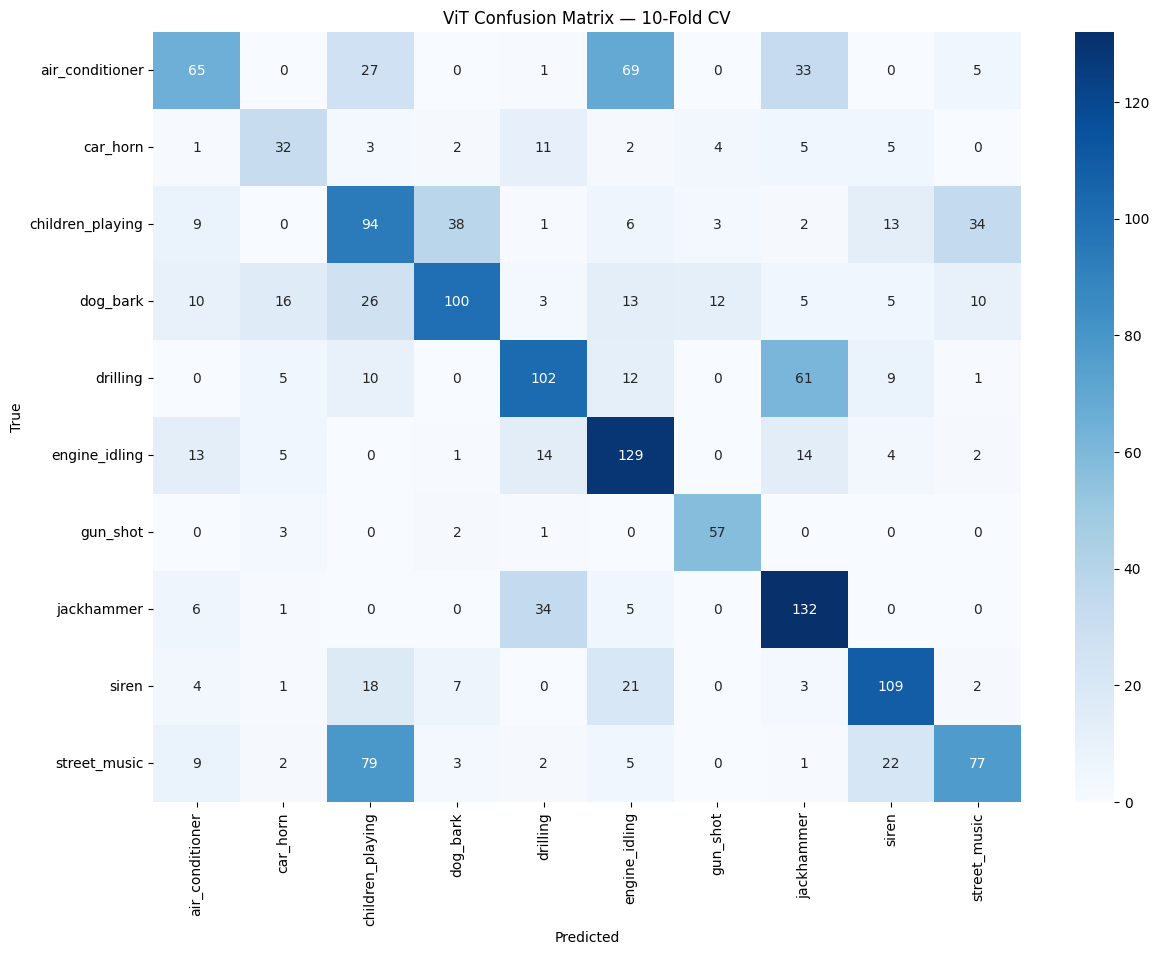

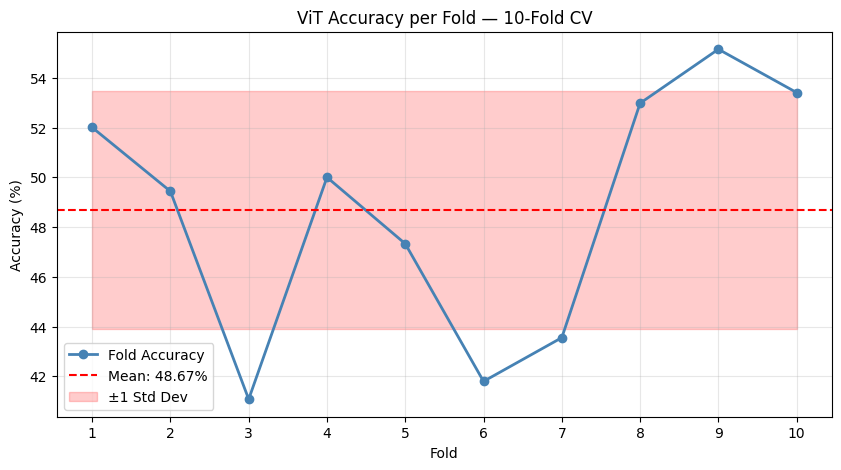


 All done! Check Output tab for saved files.


In [5]:
# ─────────────────────────────────────────
# Resume setup — copy from previous session
# ─────────────────────────────────────────
prev_output = '/kaggle/input/notebooks/sabrinsltn/urbansound8k-vit'   # ← change this

if os.path.exists(prev_output):
    print("Previous output found — copying files...")

    # Copy progress file
    prog_src = f'{prev_output}/cv_progress.json'
    if os.path.exists(prog_src):
        shutil.copy(prog_src, '/kaggle/working/cv_progress.json')
        print("Progress file copied")

    # Copy saved model weights
    for fold in range(1, 11):
        src = f'{prev_output}/vit_fold{fold}.keras'
        dst = f'/kaggle/working/vit_fold{fold}.keras'
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f" Fold {fold} model copied")
else:
    print("No previous output found — starting fresh")


# ─────────────────────────────────────────
# Load previous progress if exists
# ─────────────────────────────────────────
progress_path = '/kaggle/working/cv_progress.json'

if os.path.exists(progress_path):
    with open(progress_path, 'r') as f:
        progress    = json.load(f)
    all_accuracies  = progress['accuracies']
    all_losses      = progress['losses']
    all_y_true      = progress['y_true']
    all_y_pred      = progress['y_pred']
    start_fold      = progress['last_fold'] + 1
    print(f"\n Resuming from Fold {start_fold}")
    print(f"   Completed folds : {progress['last_fold']}")
    print(f"   Accuracies so far: "
          f"{[f'{a*100:.1f}%' for a in all_accuracies]}")
else:
    all_accuracies  = []
    all_losses      = []
    all_y_true      = []
    all_y_pred      = []
    start_fold      = 1
    print("\n Starting fresh from Fold 1")


# ─────────────────────────────────────────
# 10-Fold Cross Validation
# ─────────────────────────────────────────
for test_fold in range(start_fold, 11):
    print(f"\n{'='*50}")
    print(f"  Fold {test_fold}/10")
    print(f"{'='*50}")

    train_df = df[df['fold'] != test_fold].reset_index(drop=True)
    test_df  = df[df['fold'] == test_fold].reset_index(drop=True)

    # ── Train generator ──
    train_gen = UrbanSoundGenerator(
        train_df, data_path, le,
        batch_size=32,
        img_size=(64, 64),
        augment=True,
        shuffle=True
    )

    # ── Validation generator ──
    val_gen = UrbanSoundGenerator(
        test_df, data_path, le,
        batch_size=32,
        img_size=(64, 64),
        augment=False,
        shuffle=False
    )

    print(f"  Train : {len(train_df)} samples | "
          f"{len(train_gen)} batches")
    print(f"  Test  : {len(test_df)} samples  | "
          f"{len(val_gen)} batches")

    # ── Build fresh model ──
    model = build_vit_model()

    checkpoint = ModelCheckpoint(
        f'/kaggle/working/vit_fold{test_fold}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    # ── Train ──
    print(f"\n Training Fold {test_fold}...")
    with tf.device('/GPU:0'):
        model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=30,
            callbacks=[checkpoint],
            verbose=0
        )

    # ── Load best weights ──
    model.load_weights(
        f'/kaggle/working/vit_fold{test_fold}.keras'
    )

    # ── Evaluate — fresh generator ──
    eval_gen = UrbanSoundGenerator(
        test_df, data_path, le,
        batch_size=32,
        img_size=(64, 64),
        augment=False,
        shuffle=False
    )
    loss, accuracy = model.evaluate(eval_gen, verbose=0)
    print(f"\n Fold {test_fold} → "
          f"Accuracy: {accuracy*100:.2f}% | Loss: {loss:.4f}")

    all_accuracies.append(accuracy)
    all_losses.append(loss)

    # ── Collect predictions — fresh generator ──
    pred_gen = UrbanSoundGenerator(
        test_df, data_path, le,
        batch_size=32,
        img_size=(64, 64),
        augment=False,
        shuffle=False
    )
    fold_y_true = []
    fold_y_pred = []
    for i in range(len(pred_gen)):
        X_batch, y_batch = pred_gen[i]
        if len(X_batch) == 0:        # skip empty batches
            continue
        preds = model.predict(X_batch, verbose=0)
        fold_y_true.extend(np.argmax(y_batch, axis=1))
        fold_y_pred.extend(np.argmax(preds,   axis=1))

    all_y_true.extend(fold_y_true)
    all_y_pred.extend(fold_y_pred)

    # ── Save progress after every fold ──
    progress = {
        'last_fold'  : test_fold,
        'accuracies' : all_accuracies,
        'losses'     : all_losses,
        'y_true'     : [int(x) for x in all_y_true],
        'y_pred'     : [int(x) for x in all_y_pred]
    }
    with open(progress_path, 'w') as f:
        json.dump(progress, f)
    print(f"  Progress saved — "
          f"Fold {test_fold}/{10} complete")


# ─────────────────────────────────────────
# Final Results
# ─────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  ViT — 10-FOLD CROSS VALIDATION RESULTS")
print(f"{'='*50}")
for i, (acc, loss) in enumerate(
    zip(all_accuracies, all_losses), 1
):
    print(f"  Fold {i:2d} → "
          f"Accuracy: {acc*100:.2f}%  | Loss: {loss:.4f}")
print(f"{'─'*50}")
print(f"  Mean Accuracy : {np.mean(all_accuracies)*100:.2f}%")
print(f"  Std Deviation : {np.std(all_accuracies)*100:.2f}%")
print(f"  Best Fold     : Fold {np.argmax(all_accuracies)+1} "
      f"({max(all_accuracies)*100:.2f}%)")
print(f"  Worst Fold    : Fold {np.argmin(all_accuracies)+1} "
      f"({min(all_accuracies)*100:.2f}%)")

# ── Classification Report ──
print("\nClassification Report:")
print(classification_report(
    all_y_true, all_y_pred,
    target_names=le.classes_
))

# ── Confusion Matrix ──
conf_matrix = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    conf_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ViT Confusion Matrix — 10-Fold CV")
plt.savefig('/kaggle/working/vit_confusion_matrix.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Accuracy per Fold ──
n = len(all_accuracies)
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, n+1),
    [a*100 for a in all_accuracies],
    marker='o', color='steelblue',
    linewidth=2, label='Fold Accuracy'
)
plt.axhline(
    y=np.mean(all_accuracies)*100,
    color='red', linestyle='--',
    label=f'Mean: {np.mean(all_accuracies)*100:.2f}%'
)
plt.fill_between(
    range(1, n+1),
    [(np.mean(all_accuracies) -
      np.std(all_accuracies))*100] * n,
    [(np.mean(all_accuracies) +
      np.std(all_accuracies))*100] * n,
    alpha=0.2, color='red', label='±1 Std Dev'
)
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("ViT Accuracy per Fold — 10-Fold CV")
plt.xticks(range(1, n+1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/vit_accuracy_per_fold.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("\n All done! Check Output tab for saved files.")